# Convolutional Neural Networks

A Convolutional Neural Network, also known as CNN or ConvNet, is a class of neural networks that specializes in processing data that has a grid-like topology.

---

## Convolutional Neural Network Architecture

A CNN typically has three layers: a convolutional layer, a pooling layer, and a fully connected layer.

---

## Convolution Layer

The convolution layer is the core building block of the CNN. It carries the main portion of the network’s computational load.

---

Convolution Output:
 [[  3 -11 -11]
 [  5  -7 -12]
 [  5  -1  -4]]


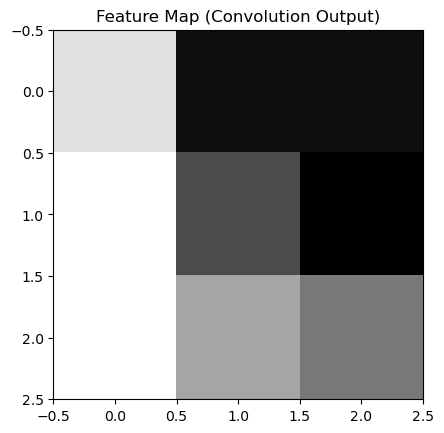

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

# Simple 5x5 image
image = np.array([
    [1, 2, 0, 1, 3],
    [4, 5, 6, 1, 0],
    [7, 8, 9, 2, 1],
    [1, 0, 2, 3, 4],
    [5, 6, 7, 8, 9]
])

# Edge detection filter (kernel)
kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

output = convolve2d(image, kernel, mode='valid')

print("Convolution Output:\n", output)

plt.imshow(output, cmap='gray')
plt.title("Feature Map (Convolution Output)")
plt.show()

---

## 2. Activation Functions (ReLU, Sigmoid, Tanh)

Activation functions introduce non-linearity.

---

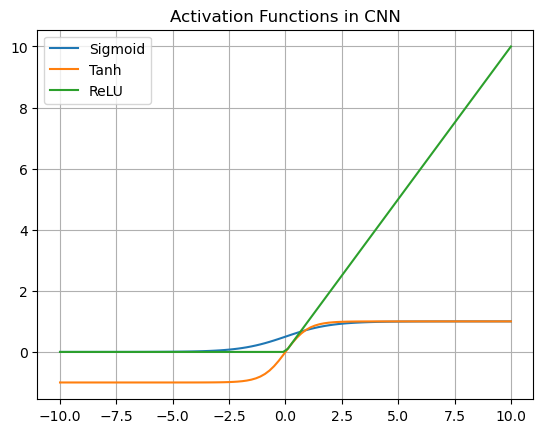

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 100)

sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)

plt.plot(x, sigmoid, label="Sigmoid")
plt.plot(x, tanh, label="Tanh")
plt.plot(x, relu, label="ReLU")

plt.title("Activation Functions in CNN")
plt.legend()
plt.grid()
plt.show()

---

## 3. Pooling Layer (Max Pooling)

Pooling reduces the size of the image and retains important features.

---


Original Image:
 [[1 3 2 4]
 [5 6 7 8]
 [1 2 0 1]
 [4 5 6 7]]
Pooled Image:
 [[6 8]
 [5 7]]


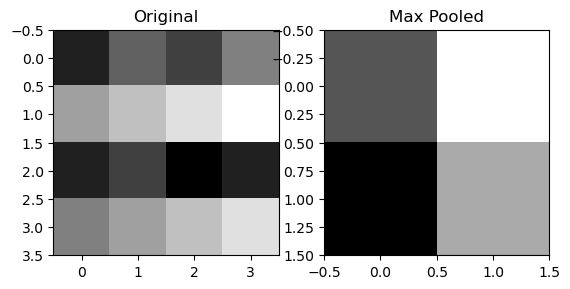

In [3]:
import numpy as np
from skimage.measure import block_reduce
import matplotlib.pyplot as plt

image = np.array([
    [1, 3, 2, 4],
    [5, 6, 7, 8],
    [1, 2, 0, 1],
    [4, 5, 6, 7]
])

# Max pooling (2x2)
pooled = block_reduce(image, (2,2), np.max)

print("Original Image:\n", image)
print("Pooled Image:\n", pooled)

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(pooled, cmap='gray')
plt.title("Max Pooled")

plt.show()

---

## 4. Full CNN Model (Fashion-MNIST Style)

A complete CNN model is used for image classification.

---

In [4]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Using digits dataset as CNN alternative (simplified)
data = load_digits()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = MLPClassifier(hidden_layer_sizes=(100, 50),
                      max_iter=500,
                      random_state=42)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9666666666666667


---
## 5. CNN Architecture Visualization (Optional Bonus – Strong Impression)

---

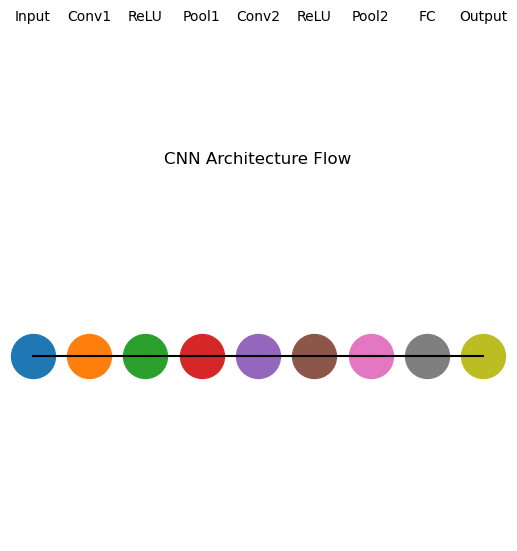

In [5]:
import matplotlib.pyplot as plt

layers = ["Input", "Conv1", "ReLU", "Pool1", "Conv2", "ReLU", "Pool2", "FC", "Output"]

for i, layer in enumerate(layers):
    plt.scatter(i, 0, s=1000)
    plt.text(i, 0.1, layer, ha='center')

for i in range(len(layers)-1):
    plt.plot([i, i+1], [0, 0], 'k-')

plt.title("CNN Architecture Flow")
plt.axis('off')
plt.show()